In [1]:
import numpy as np
from qutip import *
from scipy.linalg import sqrtm, eigvalsh
from scipy.stats import linregress
import numba
from numba import njit, prange
import pickle
import os
import time

## Fidelity
Generic definition : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \left( Tr \left[ \sqrt{ \sqrt{\rho} \sigma \sqrt{\rho} }\right] \right)^{2} $$ 
Definition for $ \rho $ Pure State and $ \sigma $ Mixed State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = \langle \psi_{\sigma} | \sigma | \psi_{\sigma} \rangle $$
Definition for Pure State : 
$$ \mathcal{F}\left( \rho, \sigma \right) = |\langle \psi_{\rho} | \psi_{\sigma} \rangle|^{2} $$
Definition for Qubits : 
$$ \mathcal{F}\left( \rho, \sigma \right) = Tr\left( \rho \, \sigma \right) + 2 \sqrt{Det\left ( \rho \right) \, Det\left ( \sigma \right)} $$
## Trace Distance
Generic definition : 
$$ \mathcal{T}\left( \rho, \sigma \right) = \frac{1}{2} Tr \left[ \sqrt{\left( \rho - \sigma \right)^{\dagger} \left( \rho - \sigma  \right)} \right] $$
### Relationship : Fuchs-van de Graaf inequality
$$ 1 - \sqrt{\mathcal{F}\left( \rho, \sigma \right)} \leq \mathcal{T}\left( \rho, \sigma \right) \leq \sqrt{1 - \mathcal{F}\left( \rho, \sigma \right)} $$

In [2]:
def fidelity_generic(rho, sigma):
    """
    Calculate the quantum fidelity between two generic density matrices.
    Formula: F(rho, sigma) = ( Tr[ sqrt( sqrt(rho) * sigma * sqrt(rho) ) ] )^2
    
    This version avoids scipy.linalg.sqrtm to prevent RuntimeWarnings, 
    using stable eigenvalue decomposition instead.
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The fidelity between rho and sigma (real number between 0 and 1).
    """
    # 1. Square root of rho using eigenvalue decomposition
    evals_rho, evecs_rho = np.linalg.eigh(rho)
    # Truncate any negative noise to 0.0 before taking the square root
    evals_rho = np.maximum(evals_rho, 0.0) 
    sqrt_rho = evecs_rho @ np.diag(np.sqrt(evals_rho)) @ evecs_rho.conj().T
    
    # 2. Inner matrix: sqrt(rho) * sigma * sqrt(rho)
    inner_matrix = sqrt_rho @ sigma @ sqrt_rho
    
    # Force exact Hermiticity to remove any small imaginary noise
    inner_matrix = 0.5 * (inner_matrix + inner_matrix.conj().T)
    
    # 3. Trace of the square root is the sum of the square roots of the eigenvalues
    evals_inner = eigvalsh(inner_matrix)
    # Again, truncate negative noise to 0.0 before square root
    evals_inner = np.maximum(evals_inner, 0.0)
    
    fidelity = np.sum(np.sqrt(evals_inner))**2
    
    # Ensure numerical errors do not push fidelity slightly above 1.0
    return min(1.0, fidelity)
    

In [3]:
@njit
def fidelity_qubit(rho, sigma):
    """
    Calculate the exact quantum fidelity between two single-qubit (2x2) density matrices.
    Formula: F(rho, sigma) = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
    """
    # Trace of the matrix product
    tr_term = np.real(np.trace(rho @ sigma))
    
    # Determinants of the two density matrices
    det_rho = np.real(np.linalg.det(rho))
    det_sigma = np.real(np.linalg.det(sigma))
    
    # FIX NUMERICO: Tronchiamo a 0 gli eventuali valori negativi infinitesimi
    det_rho = max(0.0, det_rho)
    det_sigma = max(0.0, det_sigma)
    
    # Calculate fidelity using the analytical formula for qubits
    fidelity = tr_term + 2.0 * np.sqrt(det_rho * det_sigma)
    
    return fidelity

In [4]:
def trace_distance_generic(rho, sigma):
    """
    Calculate the Trace Distance between two generic density matrices.
    Formula: T(rho, sigma) = 1/2 * Tr[ sqrt( (rho - sigma)^dagger * (rho - sigma) ) ]
    
    Parameters:
        rho (numpy.ndarray): First density matrix (NxN).
        sigma (numpy.ndarray): Second density matrix (NxN).
        
    Returns:
        float: The trace distance between rho and sigma (real number between 0 and 1).
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Force exact Hermiticity to remove numerical noise
    diff = 0.5 * (diff + diff.conj().T)
    
    # Calculate the eigenvalues of the strictly Hermitian matrix 'diff'
    eigenvalues = eigvalsh(diff)
    
    # Trace distance is half the sum of the absolute eigenvalues
    t_dist = 0.5 * np.sum(np.abs(eigenvalues))
    
    # Ensure it stays within physical bounds
    return min(1.0, t_dist)
    

In [5]:
def trace_distance_qubit(rho, sigma):
    """
    Calculate the exact Trace Distance between two single-qubit (2x2) density matrices.
    For a 2x2 traceless Hermitian matrix (rho - sigma), Det(diff) = -lambda^2 <= 0.
    Therefore, the Trace Distance simplifies to sqrt(-Det(rho - sigma)).
    
    Parameters:
        rho (numpy.ndarray): First density matrix (2x2).
        sigma (numpy.ndarray): Second density matrix (2x2).
        
    Returns:
        float: The trace distance between rho and sigma.
    """
    # Difference between the matrices
    diff = rho - sigma
    
    # Determinant of the difference
    det_diff = np.real(np.linalg.det(diff))
    
    # Since det_diff should be <= 0, -det_diff should be >= 0.
    # We use max(0.0, ...) to truncate any negative noise before applying sqrt.
    val_under_sqrt = max(0.0, -det_diff)
    
    t_dist = np.sqrt(val_under_sqrt)
    
    return min(1.0, t_dist)
    

In [ ]:
@njit(parallel=True)
def calculate_all_fidelities_numba(n_times, N_traj, 
                                   pop_L_10, cohe_L_10_01, cohe_L_01_10, pop_L_01,
                                   pop_T_10, cohe_T_10_01, cohe_T_01_10, pop_T_01):
    
    all_fidelity_list = np.zeros((n_times, N_traj), dtype=np.float64)
    
    rho_list_lindblad = np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times):
        rho_list_lindblad[t, 0, 0] = pop_L_10[t]
        rho_list_lindblad[t, 0, 1] = cohe_L_10_01[t]
        rho_list_lindblad[t, 1, 0] = cohe_L_01_10[t]
        rho_list_lindblad[t, 1, 1] = pop_L_01[t]

    for index in prange(N_traj):
        
        rho_single_traj_t = np.zeros((2, 2), dtype=np.complex128)
        
        for t in range(n_times):
            rho_single_traj_t[0, 0] = pop_T_10[t, index]
            rho_single_traj_t[0, 1] = cohe_T_10_01[t, index]
            rho_single_traj_t[1, 0] = cohe_T_01_10[t, index]
            rho_single_traj_t[1, 1] = pop_T_01[t, index]
            
            all_fidelity_list[t, index] = fidelity_qubit(rho_single_traj_t, rho_list_lindblad[t])
            
    return all_fidelity_list

## General Setup

In [ ]:
# ===========================
# General Setup for Plotting
# ===========================
# --- 1. Output Directory---
Output_dir = "../Results/Plot/Fidelity"
os.makedirs(Output_dir, exist_ok=True)

# --- 2. Global Style Settings (Matplotlib rcParams) ---
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':',
    'figure.autolayout': True # plt.tight_layout()
})

# --- 3. Automatic Figure Saving Function ---
def save_fig(fig, filename):
    """
    Saves the figure in both PNG or PDF
    """
    path_png = os.path.join(Output_dir, f"{filename}.png")
    # path_pdf = os.path.join(Output_dir, f"{filename}.pdf")  # save in pdf
    
    fig.savefig(path_png, dpi=300, bbox_inches='tight')
    # fig.savefig(path_pdf, bbox_inches='tight') # save in pdf
    print(f"Figure saved in: {Output_dir}/{filename}")

In [ ]:
# ====================================
# Physical & Simulation Parameters
# ====================================
# Theta angle in degrees, H_Coll Direction
theta_target_deg = 60.0  
theta_rad = np.radians(theta_target_deg)

# Site selector: 0 for |10>, 1 for |01>
site_index = 0

# Time step
dt = 0.01

# Number of trajectories to analyze
N_traj = 10000          

In [ ]:
# =================
# Input Data Setup
# =================
Input_dir = "../Results/Data/Complete_rho"

# Format theta and dt for filename 
theta_str = f"{theta_rad:.6f}".replace(".", "p")
dt_str = f"{dt:.6f}".replace(".", "p")

# File name
filename = f"result_theta{theta_str}_dt{dt_str}_Ntraj20000.npz"
#filename = "result_theta0p000000_dt0p010000_Ntraj20000.npz"  # only for 0.0 deg
filepath = os.path.join(Input_dir, filename)

print(f"Analisi impostata per theta = {theta_target_deg}°")
print(f"File target: {filename}")

Analisi impostata per theta = 60.0°
File target: result_theta1p047198_dt0p010000_Ntraj20000.npz


 ### Data Extraction

In [ ]:
if not os.path.exists(filepath):
    print(f"ERRORE: The file {filepath} doesn't exist. Check file name.")
else:
    # Load .npz input containing data
    data = np.load(filepath)
    
    times = data['times']
    n_times = len(times)
    
    print("Matrix extraction in progress")
    
    # =======================
    # 1. Lindblad Extraction
    # =======================
    rho_lindblad = data['rho_list_lindblad']  # 4x4 dimesion
    
    # Populations : Index (2,2) -> |10><10|, Index (1,1)  -> |01><01|    
    pop_lindblad_10 = np.real(rho_lindblad[:, 2, 2])
    pop_lindblad_01 = np.real(rho_lindblad[:, 1, 1])
    
    # Coherences: Index (2,1) -> |10><01|, Index (1, 2) -> |01><10|  ATTENTION : inverted respect to Trajectories, already inverted here
    cohe_lindblad_10_01 = rho_lindblad[:, 1, 2] 
    cohe_lindblad_01_10 = rho_lindblad[:, 2, 1]
    
    # ================================
    # 2.  Raw Trajectories Extraction
    # ================================
    
    pop_traj_10 = data['pop_00']
    pop_traj_01 = data['pop_11']
    
    cohe_traj_10_01 = data['coh_10_01'] 
    cohe_traj_01_10 = data['coh_01_10']

    print("Data extraction completed")

Estrazione matrici in corso...


Dati estratti e allineati con successo!


## Purity

$ P = Tr[\rho^2]  $

In [ ]:
# =============================================================
# Purity Check via simplified formula: p10^2 + p01^2 + 2*|c|^2 
# =============================================================

print("Starting Purity Check")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
max_deviation = 0.0

# Chunking to reduce RAM usage
CHUNK_SIZE = 5000
n_chunks = int(np.ceil(N_traj_tot / CHUNK_SIZE))

for i in range(n_chunks):
    start_idx = i * CHUNK_SIZE
    end_idx = min((i + 1) * CHUNK_SIZE, N_traj_tot)
    
    p10_chunk = pop_traj_10[:, start_idx:end_idx]
    p01_chunk = pop_traj_01[:, start_idx:end_idx]
    c_chunk = cohe_traj_10_01[:, start_idx:end_idx]
    
    # Purity p10^2 + p01^2 + 2*|c|^2
    purity_chunk = p10_chunk**2 + p01_chunk**2 + 2 * (np.abs(c_chunk)**2)
    
    # Max deviation from theroretical value 1.0
    chunk_max_dev = np.max(np.abs(1.0 - purity_chunk))
    
    if chunk_max_dev > max_deviation:
        max_deviation = chunk_max_dev

print(f"Check completed in {time.time() - start_time:.4f} seconds.")
print(f"Maximum deviation from ideal purity (1.0): {max_deviation:.4e}")

# Automatic evaluation of the result
if max_deviation < 1e-10:
    print("\n✅ Test Passed: all trajectoreis are always perfectly pure")
else:
    print("\n⚠️ Warning: Found a significant deviation from purity. Check the normalization in the simulator.")

Inizio il controllo di purezza su tutte le traiettorie e tutti i tempi...
Controllo completato in 2.7630 secondi.
Deviazione massima dalla purezza ideale (1.0): 1.3323e-15

✅ TEST SUPERATO: Tutte le traiettorie mantengono uno stato perfettamente puro!


## Fidelity calculation

In [ ]:
# ==========================================================================
# COMPLETE FIDELITY CALCULATION 
# Fidelity for Qubit: F = Tr(rho * sigma) + 2 * sqrt(Det(rho) * Det(sigma))
# ==========================================================================

all_fidelity_list = calculate_all_fidelities_numba(
    n_times, N_traj,
    pop_lindblad_10, cohe_lindblad_10_01, cohe_lindblad_01_10, pop_lindblad_01,
    pop_traj_10, cohe_traj_10_01, cohe_traj_01_10, pop_traj_01)

In [ ]:
# ========================================================
# SIMPLIFIED FIDELITY CALCULATION - (ON THE FLY)
# Fidelity for Pure and mixed states: F = Tr(rho * sigma) 
# ========================================================

print("Starting fidelity calculation")
start_time = time.time()

n_times, N_traj_tot = pop_traj_10.shape
N_traj_plot = N_traj_tot

# Prepariamo la heatmap direttamente in float32 (dimezza la RAM vs float64)
fid_bins = 150
fid_edges = np.linspace(0.0, 1.0, fid_bins + 1)
heatmap_image = np.zeros((fid_bins, n_times), dtype=np.float32)

for t in range(n_times):
    P00_t  = pop_traj_10[t, :N_traj_plot]
    P11_t  = pop_traj_01[t, :N_traj_plot]
    C10_t  = cohe_traj_10_01[t, :N_traj_plot]
    C01_t  = cohe_traj_01_10[t, :N_traj_plot]

    P00_L  = pop_lindblad_10[t]
    P11_L  = pop_lindblad_01[t]
    C10_L  = cohe_lindblad_10_01[t]  
    C01_L  = cohe_lindblad_01_10[t]   

    # Tr(rho_traj * rho_L) = P00_traj * P00_L + C01_traj * C10_L + C10_traj * C01_L + P11_traj * P11_L
    fid_t = np.real(
            P00_t * P00_L +   # P00_traj * P00_L 
            C01_t * C10_L +   # C01_traj * C10_Lind
            C10_t * C01_L +   # C10_traj * C01_Lind
            P11_t * P11_L)    # P11_traj * P11_L

    counts, _ = np.histogram(fid_t, bins=fid_edges)
    heatmap_image[:, t] = counts

print(f"Calculation completed in {time.time() - start_time:.4f} seconds")


Inizio calcolo Fidelity on-the-fly (Zero-RAM)...
Calcolo completato in 3.1180 secondi!
RAM heatmap: 6.0 MB  (vs ~1600 MB della vecchia fidelity_matrix)


## Plot 

In [ ]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from IPython.display import Image, display, Math

In [ ]:
# ==========================================
# Fidelity for Avg Traj vs Lindblad in time
# ==========================================
N_list = [100, 1000, 10000]  # Trajectories to average over for the fidelity plot

plt.figure(figsize=(10, 5))

for N in N_list:
    # Avg of the 4 components over N trajectories (shape: n_times)
    pop_10_m   = np.mean(pop_traj_10[:,    :N], axis=1)
    pop_01_m   = np.mean(pop_traj_01[:,    :N], axis=1)
    coh_1001_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    coh_0110_m = np.mean(cohe_traj_01_10[:, :N], axis=1)

    # Rebuild the average density matrix for each time step
    rho_list_avg = np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times) : 
        rho_list_avg[t] = [[pop_10_m[t], coh_1001_m[t]],[coh_0110_m[t], pop_01_m[t]]]

    # Rebuild the Lindblad density matrix for each time step
    rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)
    for t in range(n_times) : 
        rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]

    # Fidelity Calculation for each time step
    fidelity_list = np.zeros((n_times), dtype=np.float32)
    for t in range(n_times) : 
        fidelity_list[t] = fidelity_qubit(rho_list_avg[t], rho_list_lindblad[t])

    # -----
    # Plot 
    # -----
    alpha_val = 0.6 if N < 10000 else 1.0
    lw = 1.5 if N < 10000 else 2.5
    plt.plot(times, fidelity_list, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)

plt.xlabel("Time steps")
plt.ylabel("Fidelity $F(\\rho_{mean}, \\rho_L)$")
plt.title(f"Evolution in time of Avg Fidelity vs Lindblad | $\\theta$ = {theta_target_deg}°")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# ===============================
# PLOT HEATMAP FIDELITY COMPLETE
# ===============================

all_fidelity_list = np.array(all_fidelity_list).T
all_fidelity_list.shape

# all_fidelity_list has shape (n_trajectories, n_timesteps)
#arcos = 0.5 * (np.arccos(2 * all_fidelity_list -1))

n_traj, n_times = all_fidelity_list.shape
times = np.arange(n_times)  # oppure il tuo array temporale reale

# Bin Parameters
n_bins = 50  #number of bins

# Heatmap build-up
fidelity_bins = np.linspace(0, 1, n_bins + 1)
heatmap = np.zeros((n_bins, n_times))

for t in range(n_times):
    counts, _ = np.histogram(all_fidelity_list[:, t], bins=fidelity_bins)
    heatmap[:, t] = counts

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    heatmap,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0, 1],
    cmap='viridis',
    interpolation='nearest'
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Numero di traiettorie', fontsize=12)

ax.set_xlabel('Tempo', fontsize=12)
ax.set_ylabel('Fidelity', fontsize=12)
ax.set_title('Distribuzione della Fidelity nel tempo', fontsize=14)

plt.tight_layout()
plt.show()

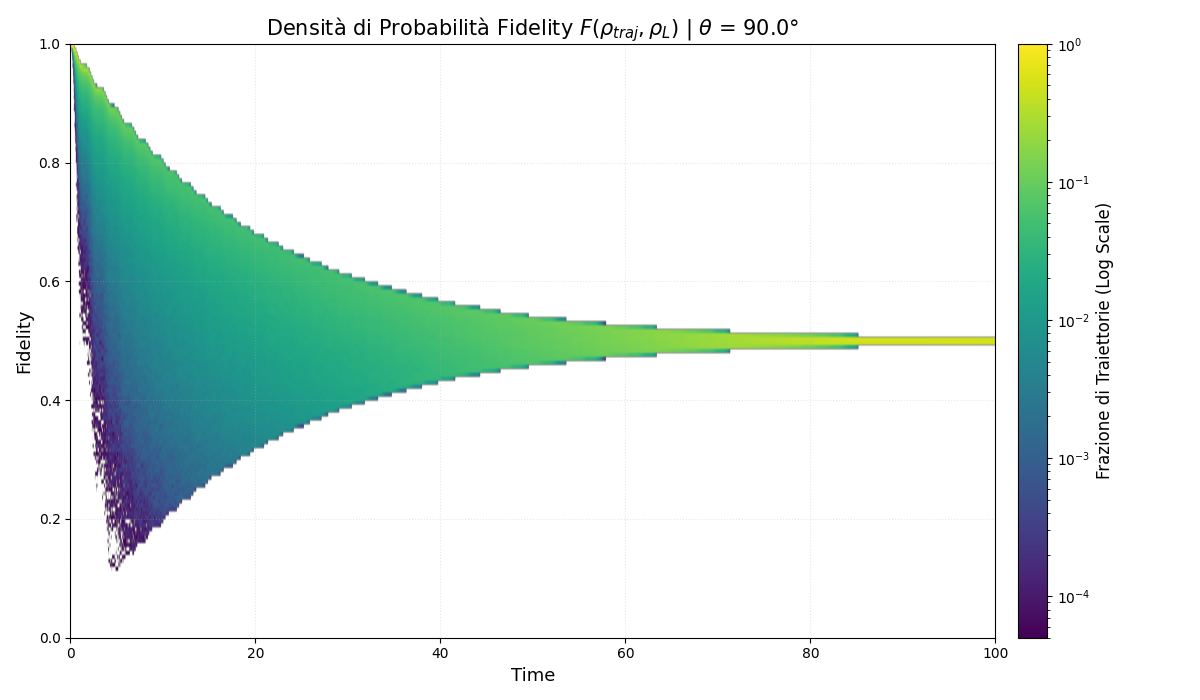

In [ ]:
# =================================
# PLOT HEATMAP FIDELITY SIMPLIFIED
# =================================
fig, ax = plt.subplots(figsize=(12, 7))

heatmap_masked = np.ma.masked_where(heatmap_image == 0, heatmap_image)
vmin_val = 1.0 / N_traj_plot

image = ax.imshow(
    heatmap_masked,
    aspect='auto',
    origin='lower',
    extent=[times[0], times[-1], 0.0, 1.0],
    cmap='viridis',
    norm=LogNorm(vmin=vmin_val, vmax=1.0)
)

cbar = fig.colorbar(image, ax=ax, pad=0.02)
cbar.set_label('Frazione di Traiettorie (Log Scale)', fontsize=12)

ax.set_title(f"Densità di Probabilità Fidelity $F(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°", fontsize=15)
ax.set_xlabel("Time", fontsize=13)
ax.set_ylabel("Fidelity", fontsize=13)
ax.grid(alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()


In [ ]:
# =================================================================
# Fidelity Calculation for a Single Trajectory vs Lindblad in time 
# =================================================================

# Selected trajectory
index = 100

# Rebuild the Trajectory density matrix for each time step
rho_list_single_traj = np.zeros((n_times, 2, 2), dtype=np.complex128)
for t in range(n_times) : 
    rho_list_single_traj[t] = [[pop_traj_10[t, index], cohe_traj_10_01[t, index]],[cohe_traj_01_10[t, index], pop_traj_01[t, index]]]

# Rebuild the Lindblad density matrix for each time step
rho_list_lindblad= np.zeros((n_times, 2, 2), dtype=np.complex128)
for t in range(n_times) : 
    rho_list_lindblad[t] = [[pop_lindblad_10[t], cohe_lindblad_10_01[t]],[cohe_lindblad_01_10[t], pop_lindblad_01[t]]]

# Fidelity Calculation for each time step
fidelity_list = np.zeros((n_times), dtype=np.float32)
for t in range(n_times) : 
    fidelity_list[t] = fidelity_qubit(rho_list_single_traj[t], rho_list_lindblad[t])

# -----
# Plot 
# -----
fig05, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(times, fidelity_list, label=f"Traj = {index}")

ax.set_xlabel("Time steps")
ax.set_ylabel("Fidelity $F(\\rho_{Traj}, \\rho_L)$")
ax.set_title(f"Evoluzione della Fidelity tra singola Traj e Lindblad | $\\theta$ = {theta_target_deg}°")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
    

## Trace Distance calculation

In [ ]:
# DA RIFARE 
# print("Inizio calcolo Trace Distance on-the-fly (Zero-RAM)...")
# start_time = time.time()

# # 1. Prepariamo l'immagine vuota e i bins (da 0 a 1)
# td_bins = 150
# td_edges = np.linspace(0.0, 1.0, td_bins + 1)
# heatmap_image_td = np.zeros((td_bins, n_times))

# # 2. Ciclo sul tempo: estraiamo solo la riga corrente, calcoliamo e facciamo l'istogramma
# for t in range(n_times):
#     # Estraiamo i dati di tutte le N_traj ma SOLO per l'istante t (pesa pochissimi Kilobyte!)
#     p10_t = pop_traj_10[t, :N_traj]
#     p01_t = pop_traj_01[t, :N_traj]
#     c10_01_t = cohe_traj_10_01[t, :N_traj]
#     c01_10_t = cohe_traj_01_10[t, :N_traj]
    
#     # Lindblad al tempo t (sono singoli numeri)
#     L10_t = pop_lindblad_10[t]
#     L01_t = pop_lindblad_01[t]
#     L10_01_t = cohe_lindblad_10_01[t]
#     L01_10_t = cohe_lindblad_01_10[t]
    
#     # Calcoliamo la differenza vettorizzata solo per l'istante t
#     D_10 = p10_t - L10_t
#     D_01 = p01_t - L01_t
#     D_10_01 = c10_01_t - L10_01_t
#     D_01_10 = c01_10_t - L01_10_t
    
#     # Determinante e Trace Distance per l'istante t
#     det_diff = np.real(D_10 * D_01 - D_10_01 * D_01_10)
#     td_t = np.sqrt(np.maximum(0.0, -det_diff))
    
#     # Generiamo l'istogramma della colonna e normalizziamo
#     counts, _ = np.histogram(td_t, bins=td_edges)
#     heatmap_image_td[:, t] = counts / N_traj

# print(f"Calcolo e generazione mappa completati in {time.time() - start_time:.4f} secondi!")

Inizio calcolo Trace Distance on-the-fly (Zero-RAM)...
Calcolo e generazione mappa completati in 3.6642 secondi!


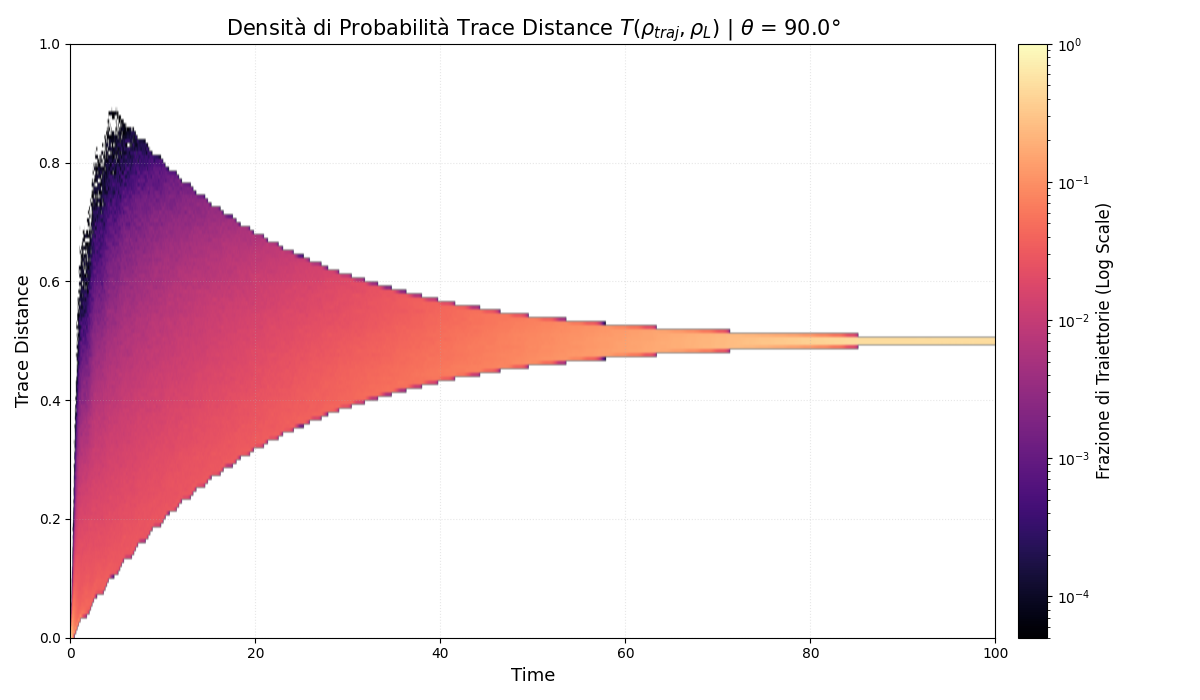

In [ ]:
# ==========================================================
# PLOT HEATMAP TRACE DISTANCE
# ==========================================================
# fig, ax = plt.subplots(figsize=(12, 7))

# # Maschera per le zone senza traiettorie (restano bianche)
# heatmap_masked_td = np.ma.masked_where(heatmap_image_td == 0, heatmap_image_td)

# vmin_val = 1.0 / N_traj
# image_td = ax.imshow(
#     heatmap_masked_td, 
#     aspect='auto', 
#     origin='lower', 
#     extent=[times[0], times[-1], 0.0, 1.0], 
#     cmap='magma',
#     norm=LogNorm(vmin=vmin_val, vmax=1.0) 
# )

# cbar = fig.colorbar(image_td, ax=ax, pad=0.02)
# cbar.set_label('Frazione di Traiettorie (Log Scale)', fontsize=12)

# ax.set_title(f"Densità di Probabilità Trace Distance $T(\\rho_{{traj}}, \\rho_{{L}})$ | $\\theta$ = {theta_target_deg}°", fontsize=15)
# ax.set_xlabel("Time", fontsize=13)
# ax.set_ylabel("Trace Distance", fontsize=13)
# ax.grid(alpha=0.3, linestyle=':')

# plt.tight_layout()
# plt.show()

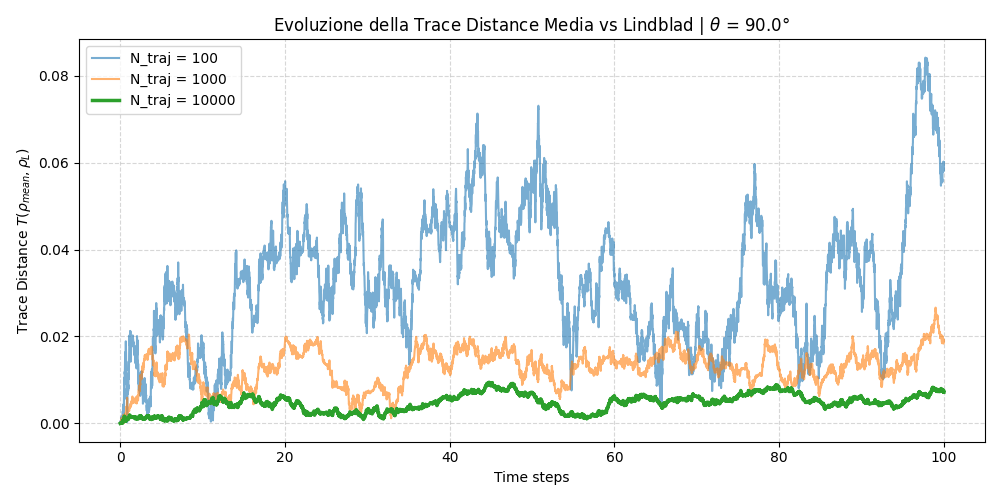

In [ ]:
# ==========================================================
# Calcolo della Trace Distance della Media per N traiettorie
# ==========================================================

N_list = [100, 1000, 10000]

plt.figure(figsize=(10, 5))

for N in N_list:
    # 1. Calcolo rapido delle popolazioni e coerenze medie per N traiettorie
    pop_10_m = np.mean(pop_traj_10[:, :N], axis=1)
    pop_01_m = np.mean(pop_traj_01[:, :N], axis=1)
    cohe_10_01_m = np.mean(cohe_traj_10_01[:, :N], axis=1)
    cohe_01_10_m = np.mean(cohe_traj_01_10[:, :N], axis=1)
    
    # 2. Differenza vettorizzata con Lindblad
    D_10_m = pop_10_m - pop_lindblad_10
    D_01_m = pop_01_m - pop_lindblad_01
    D_10_01_m = cohe_10_01_m - cohe_lindblad_10_01
    D_01_10_m = cohe_01_10_m - cohe_lindblad_01_10
    
    # 3. Determinante della differenza
    det_diff_m = np.real(D_10_m * D_01_m - D_10_01_m * D_01_10_m)
    
    # 4. Trace Distance = sqrt(-Det)
    val_under_sqrt_m = np.maximum(0.0, -det_diff_m)
    td_mean_array = np.sqrt(val_under_sqrt_m)
    
    # Stile dinamico: la curva a 10000 sarà la più marcata
    alpha_val = 0.6 if N < 10000 else 1.0
    lw = 1.5 if N < 10000 else 2.5
    
    plt.plot(times, td_mean_array, label=f'N_traj = {N}', alpha=alpha_val, linewidth=lw)
    
plt.xlabel("Time steps")
plt.ylabel("Trace Distance $T(\\rho_{mean}, \\rho_L)$")
plt.title(f"Evolution in time of Avg Trace Distance vs Lindblad | $\\theta$ = {theta_target_deg}°")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

#plt.ylim(-0.005, 0.1)

plt.tight_layout()
plt.show()